# Diagnóstico del modelo final: sobreajuste, sesgo y robustez

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

El modelo elegido para la competencia es **dos etapas + NB-LR** (Mejora 7), con una exactitud de 0,9023 en la comparación de 15 particiones y 0,90777 en el puntaje público de Kaggle. Antes de entregarlo conviene revisar si es confiable más allá de esa cifra:

1. **Sobreajuste:** si aprende patrones que se generalizan o si memoriza el conjunto de entrenamiento.
2. **Sesgo entre clases:** si favorece alguna etiqueta y si sus probabilidades son confiables.
3. **Sesgo por tipo de reseña:** si rinde parejo en reseñas con y sin tildes, cortas y largas, y según su estructura.
4. **Robustez:** cómo cambia su desempeño ante cambios realistas del texto que podrían aparecer en datos reales.
5. **Parecido entre los datos de la competencia y los de entrenamiento:** de eso depende que el puntaje final se parezca al de la validación cruzada.

La Mejora 8 ya midió la diferencia entre entrenamiento y validación de varios modelos, el sesgo entre clases en su partición de validación y la curva de aprendizaje de la regresión logística. Este notebook se concentra en el modelo elegido y en lo que no se había revisado. Para tener una referencia simple, todo se compara con la regresión logística por bloques con la cláusula corregida.

Este notebook no entrena un modelo nuevo ni genera envíos para Kaggle.

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer
from scipy import sparse

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']
RUTA_DATOS = os.path.join('..', 'data')
RUTA_ENVIOS = os.path.join('..', 'submissions')

## 2. Datos

Para tener la mayor cantidad posible de predicciones que analizar, se usa validación cruzada de 5 particiones sobre las 12.000 reseñas etiquetadas: cada reseña recibe una predicción de un modelo que no la vio al entrenarse. Así todos los análisis se hacen con 12.000 predicciones fuera de muestra, en vez de las 2.400 de un solo conjunto de prueba.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
X = train[['text']]
y = train['label']

# Validación cruzada de 5 particiones sobre las 12.000 reseñas: cada reseña recibe una predicción
# de un modelo que no la vio al entrenarse (predicción "fuera de muestra")
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
particiones = list(kfold.split(X, y))
print('train:', train.shape, '| eval:', evaluacion.shape)

train: (12000, 3) | eval: (3000, 2)


## 3. Modelos que se revisan

Las celdas siguientes copian sin cambios el código del notebook de la Mejora 7: el preprocesamiento, la corrección de la cláusula final, NB-LR y la clase `ModeloDosEtapasNBLR`. Se revisan dos modelos:

- **Dos etapas + NB-LR (Mejora 7):** el modelo elegido, con `C_etapa2 = 0,1`, como en la Mejora 7.
- **Regresión logística corregida:** la regresión logística L1 (`C = 10`) sobre los tres bloques de TF-IDF con la cláusula corregida. Es el modelo más simple de los buenos y sirve para saber si un problema es del modelo complejo o de los datos.

In [3]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [4]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])

In [5]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques del notebook principal, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    """Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    """

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [6]:
K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def separar_trozos(texto):
    """Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector."""
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]

In [7]:
class ModeloDosEtapasNBLR(ClassifierMixin, BaseEstimator):
    """Modelo en dos etapas de la Mejora 1 al que se le agregan las probabilidades de NB-LR.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de negativo, neutral y positivo).
    Etapa 2: regresión logística sobre los puntajes de los últimos trozos, las probabilidades de los
    modelos por bloques (regresión logística, Naive Bayes y NB-LR) y el comienzo de las oraciones con opinión.
    """

    def __init__(self, C_etapa1=3, C_etapa2=1, C_nblr=0.3, alpha_nblr=1.0, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_nblr = C_nblr
        self.alpha_nblr = alpha_nblr
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_corregida().fit(datos)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)
        prob_nblr = comp['nblr'].predict_proba(datos)

        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]
            polaridad = P[:, 2] - P[:, 0]
            con_opinion = np.where(P[:, 1] < 0.5)[0]
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]
            fila += list(prob_bayes[k])
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            fila += list(prob_nblr[k])
            filas.append(fila)
        return np.array(filas)

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Atributos de la etapa 2 calculados fuera de muestra (validación cruzada interna)
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        return self

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [8]:
modelos = {
    'Dos etapas + NB-LR (Mejora 7)': ModeloDosEtapasNBLR(C_etapa2=0.1),
    'Regresión logística corregida': Pipeline([
        ('rep', construir_representacion_corregida()),
        ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)),
    ]),
}
ELEGIDO, SIMPLE = list(modelos)

## 4. Predicciones fuera de muestra

`cross_validate` entrena cada modelo en las 5 particiones y devuelve los modelos entrenados (`return_estimator=True`) y la exactitud en entrenamiento (`return_train_score=True`). Con esos modelos se obtienen las probabilidades fuera de muestra de cada reseña, que se reutilizan en el resto del notebook.

In [9]:
resultados_cv = {}
prob_oof = {}
for nombre, modelo in modelos.items():
    resultados_cv[nombre] = cross_validate(modelo, X, y, cv=particiones, scoring='accuracy',
                                           return_train_score=True, return_estimator=True, n_jobs=-1)
    P = np.zeros((len(X), 3))
    for estimador, (_, idx_val) in zip(resultados_cv[nombre]['estimator'], particiones):
        P[idx_val] = estimador.predict_proba(X.iloc[idx_val])
    prob_oof[nombre] = P

clases = np.array(sorted(y.unique()))
pred_oof = {nombre: clases[P.argmax(axis=1)] for nombre, P in prob_oof.items()}
acierto = {nombre: pred == y.values for nombre, pred in pred_oof.items()}
for nombre in modelos:
    print(f'{nombre:32s} exactitud fuera de muestra: {acierto[nombre].mean():.4f}')

Dos etapas + NB-LR (Mejora 7)    exactitud fuera de muestra: 0.9027
Regresión logística corregida    exactitud fuera de muestra: 0.8978


## 5. Sobreajuste

### 5.1 Entrenamiento frente a validación

In [10]:
tabla_brecha = pd.DataFrame({
    nombre: {'Exactitud entrenamiento': r['train_score'].mean(),
             'Exactitud validación': r['test_score'].mean(),
             'Diferencia': r['train_score'].mean() - r['test_score'].mean(),
             'Desviación entre particiones (validación)': r['test_score'].std(ddof=1)}
    for nombre, r in resultados_cv.items()}).T
tabla_brecha.round(4)

,Exactitud entrenamiento,Exactitud validación,Diferencia,Desviación entre particiones (validación)
Dos etapas + NB-LR (Mejora 7),0.9906,0.9027,0.0880,0.0032
Regresión logística corregida,0.9996,0.8978,0.1018,0.0050


El modelo elegido acierta el 99,1% de las reseñas con las que se entrenó y el 90,3% de las que no vio: 8,8 puntos de diferencia. La regresión logística acierta casi el 100% en entrenamiento y el 89,8% fuera de muestra (10,2 puntos). La exactitud de validación es muy estable entre particiones: la desviación del modelo elegido es de 0,32 puntos. Una diferencia así suele leerse como sobreajuste, pero antes conviene ver de dónde viene.

### 5.2 ¿De dónde viene la diferencia?

In [11]:
def clave_oracion(oracion):
    return re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).strip()


finales = Counter(clave_oracion(separar_oraciones(t)[-1]) for t in X['text'])
cierres = {o for o, n in finales.items() if n >= 12}
ADITIVOS = ('por otro', 'de paso', 'por cierto', 'ademas')


def tipo_de_resena(texto, etiqueta):
    if etiqueta == 'neutral':
        return 'Neutral'
    if clave_oracion(separar_oraciones(texto)[-1]) in cierres:
        return 'Termina en un cierre ambiguo'
    comienzos = [comienzo_oracion(o) for o in separar_oraciones(texto)[1:]]
    if any(c.startswith(a) for c in comienzos for a in ADITIVOS):
        return 'Conector aditivo'
    if re.search(r'\b(pero|aunque|aun asi|con todo|al final|eso si|ahora|en cambio)\b', quitar_tildes(texto.lower())):
        return 'Conector adversativo'
    return 'Sin conector de contraste'


tipo = pd.Series([tipo_de_resena(t, e) for t, e in zip(X['text'], y)], index=y.index)
tipo.value_counts()

Conector adversativo            3717
Neutral                         3576
Sin conector de contraste       2561
Conector aditivo                1212
Termina en un cierre ambiguo     934
Name: count, dtype: int64

In [12]:
# Exactitud en entrenamiento: el modelo de la primera partición, evaluado sobre las reseñas con que se entrenó
idx_ent, _ = particiones[0]
modelo_1 = resultados_cv[ELEGIDO]['estimator'][0]
acierto_ent = pd.Series(modelo_1.predict(X.iloc[idx_ent]) == y.values[idx_ent], index=y.index[idx_ent])

brecha_grupos = pd.DataFrame({
    'reseñas': tipo.value_counts(),
    'exactitud entrenamiento': acierto_ent.groupby(tipo[idx_ent]).mean(),
    'exactitud fuera de muestra': pd.Series(acierto[ELEGIDO], index=y.index).groupby(tipo).mean(),
})
brecha_grupos['diferencia'] = brecha_grupos['exactitud entrenamiento'] - brecha_grupos['exactitud fuera de muestra']
brecha_grupos.sort_values('diferencia', ascending=False).round(3)

,reseñas,exactitud entrenamiento,exactitud fuera de muestra,diferencia
Termina en un cierre ambiguo,934,0.973,0.503,0.470
Conector aditivo,1212,0.964,0.825,0.139
Sin conector de contraste,2561,0.994,0.920,0.074
Conector adversativo,3717,0.995,0.925,0.070
Neutral,3576,1.000,0.998,0.002


Casi toda la diferencia está en las reseñas ambiguas. En las que terminan en un cierre ambiguo, el modelo acierta el 97,3% de las que vio en entrenamiento y solo el 50,3% de las que no vio: aprende de memoria etiquetas que parecen azarosas. En las de conector aditivo la diferencia es de 14 puntos, en las de una opinión clara de unos 7 puntos y en las neutrales prácticamente cero.

Es decir, el sobreajuste consiste sobre todo en memorizar las reseñas ambiguas del entrenamiento. Eso no parece afectar el desempeño en reseñas nuevas, porque en esas reseñas ningún modelo supera el azar. Pero explica por qué la exactitud de entrenamiento no es un buen indicador del desempeño real.

### 5.3 Curva de aprendizaje

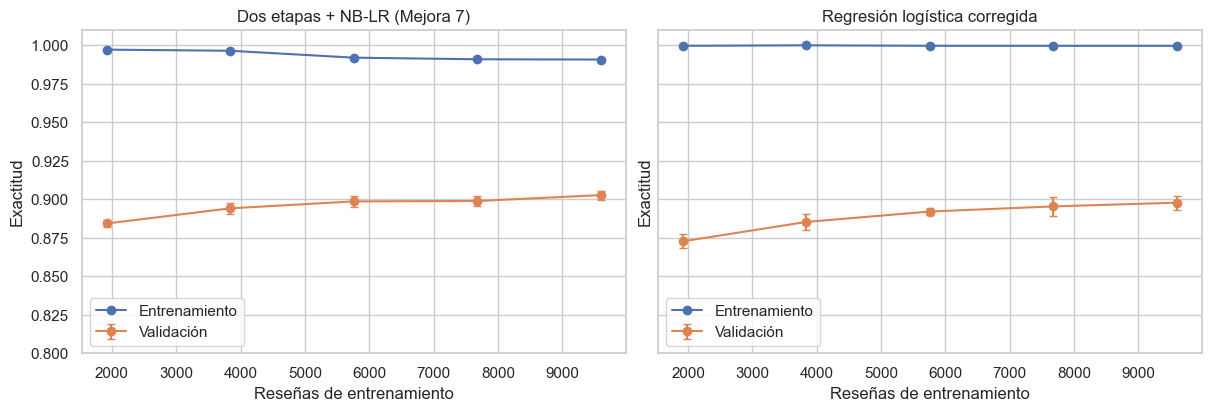

Dos etapas + NB-LR (Mejora 7)


,reseñas de entrenamiento,entrenamiento,validación,desv. validación
0,1920,0.9971,0.8842,0.0023
1,3840,0.9964,0.8941,0.0037
2,5760,0.9919,0.8986,0.0037
3,7680,0.9908,0.8988,0.0035
4,9600,0.9906,0.9027,0.0029


Regresión logística corregida


,reseñas de entrenamiento,entrenamiento,validación,desv. validación
0,1920,0.9996,0.8727,0.0046
1,3840,0.9999,0.8853,0.0050
2,5760,0.9996,0.8920,0.0024
3,7680,0.9996,0.8953,0.0059
4,9600,0.9996,0.8978,0.0045


In [13]:
tamanos = [0.2, 0.4, 0.6, 0.8, 1.0]
curvas = {}
for nombre, modelo in modelos.items():
    n, ent, val = learning_curve(modelo, X, y, train_sizes=tamanos, cv=particiones, scoring='accuracy', n_jobs=-1)
    curvas[nombre] = pd.DataFrame({'reseñas de entrenamiento': n, 'entrenamiento': ent.mean(axis=1),
                                   'validación': val.mean(axis=1), 'desv. validación': val.std(axis=1)})

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharey=True)
for eje, (nombre, curva) in zip(ax, curvas.items()):
    eje.plot(curva['reseñas de entrenamiento'], curva['entrenamiento'], marker='o', label='Entrenamiento')
    eje.errorbar(curva['reseñas de entrenamiento'], curva['validación'], yerr=curva['desv. validación'],
                 marker='o', capsize=3, label='Validación')
    eje.set(title=nombre, xlabel='Reseñas de entrenamiento', ylabel='Exactitud', ylim=(0.80, 1.01))
    eje.legend()
plt.show()

for nombre, curva in curvas.items():
    print(nombre)
    display(curva.round(4))

La exactitud de validación del modelo elegido sube de 0,884 con 1.920 reseñas a 0,903 con 9.600, y todavía no se estabiliza del todo: entre 7.680 y 9.600 reseñas sube 0,4 puntos. La de entrenamiento baja levemente (de 0,997 a 0,991), como es normal cuando el modelo tiene que ajustarse a más ejemplos. Las dos curvas se acercan, pero despacio. Más datos del mismo tipo ayudarían algo, del orden de décimas de punto, sin cerrar la brecha, porque buena parte de ella son las reseñas ambiguas. La regresión logística se comporta igual, unos 0,5 puntos por debajo y con la exactitud de entrenamiento siempre cerca del 100%.

### 5.4 ¿Coincide la validación cruzada con Kaggle?

In [14]:
# Comparación con 15 particiones (notebook de la Mejora 7) y puntaje público de Kaggle de dos etapas + NB-LR
exactitud_15 = 0.9023
aciertos_publico, n_publico = 817, 900
n_privado = 3000 - n_publico

error_publico = np.sqrt(exactitud_15 * (1 - exactitud_15) / n_publico)
error_privado = np.sqrt(exactitud_15 * (1 - exactitud_15) / n_privado)
print(f'Puntaje público: {aciertos_publico / n_publico:.4f} ({aciertos_publico} de {n_publico})')
print(f'Lo esperado según la validación cruzada: {exactitud_15:.4f} +/- {1.96 * error_publico:.4f} (95%, con {n_publico} reseñas)')
print(f'Diferencia: {aciertos_publico / n_publico - exactitud_15:+.4f}, es decir, {(aciertos_publico / n_publico - exactitud_15) / error_publico:.1f} errores estándar')
print(f'\nRango esperado para el puntaje final ({n_privado} reseñas): '
      f'{exactitud_15 - 1.96 * error_privado:.4f} a {exactitud_15 + 1.96 * error_privado:.4f} (95%)')

Puntaje público: 0.9078 (817 de 900)
Lo esperado según la validación cruzada: 0.9023 +/- 0.0194 (95%, con 900 reseñas)
Diferencia: +0.0055, es decir, 0.6 errores estándar

Rango esperado para el puntaje final (2100 reseñas): 0.8896 a 0.9150 (95%)


El puntaje público (0,9078) está 0,55 puntos por encima de la validación cruzada (0,9023), apenas 0,6 errores estándar: es completamente compatible. No hay señales de que el modelo esté sobreajustado al entrenamiento ni a la forma en que se eligió con validación cruzada. Para el puntaje final, que normalmente se calcula con las 2.100 reseñas restantes, se espera una exactitud de entre 0,890 y 0,915 (intervalo del 95%).

## 6. Sesgo entre clases y confianza de las probabilidades

### 6.1 ¿Favorece alguna clase?

,% negativo,% neutral,% positivo
Real,35.1,29.8,35.1
Dos etapas + NB-LR (Mejora 7),34.9,29.9,35.1
Regresión logística corregida,34.3,30.2,35.5


,negativo → positivo,positivo → negativo,errores con neutral,sensibilidad negativo,sensibilidad neutral,sensibilidad positivo
Dos etapas + NB-LR (Mejora 7),575.0,560.0,33.0,0.862,0.998,0.863
Regresión logística corregida,609.0,533.0,85.0,0.849,0.996,0.864


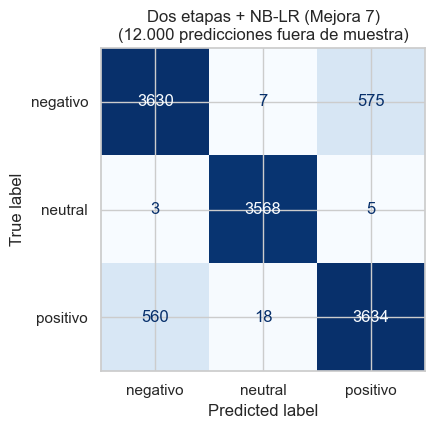

In [15]:
filas = {'Real': y.value_counts(normalize=True).reindex(ORDEN_CLASES)}
for nombre, pred in pred_oof.items():
    filas[nombre] = pd.Series(pred).value_counts(normalize=True).reindex(ORDEN_CLASES)
display((pd.DataFrame(filas).T * 100).round(1).rename(columns=lambda c: f'% {c}'))

resumen = {}
for nombre, pred in pred_oof.items():
    resumen[nombre] = {
        'negativo → positivo': int(((y == 'negativo') & (pred == 'positivo')).sum()),
        'positivo → negativo': int(((y == 'positivo') & (pred == 'negativo')).sum()),
        'errores con neutral': int((((y == 'neutral') | (pred == 'neutral')) & (y != pred)).sum()),
        **{f'sensibilidad {c}': ((pred == c) & (y == c)).sum() / (y == c).sum() for c in ORDEN_CLASES},
    }
display(pd.DataFrame(resumen).T.round(3))

fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay.from_predictions(y, pred_oof[ELEGIDO], labels=ORDEN_CLASES, cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'{ELEGIDO}\n(12.000 predicciones fuera de muestra)')
plt.show()

El modelo elegido no favorece ninguna clase. Predice 34,9% de negativos, 29,9% de neutrales y 35,1% de positivos, casi idéntico a la distribución real (35,1%, 29,8% y 35,1%). Confunde negativos con positivos (575) y positivos con negativos (560) en cantidades parecidas, y su sensibilidad es la misma en las dos clases (0,862 y 0,863).

La regresión logística sí tiene la leve inclinación hacia `positivo` que encontró la Mejora 8 (609 contra 533 confusiones) y comete más del doble de errores relacionados con `neutral` (85 contra 33). El modelo en dos etapas corrige ese sesgo.

### 6.2 ¿Son confiables sus probabilidades?

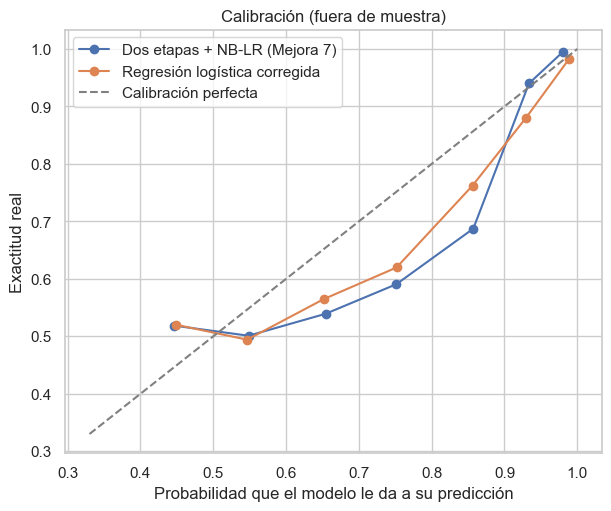

Dos etapas + NB-LR (Mejora 7)


,reseñas,confianza_media,exactitud
rango,,,
"(0.329, 0.5]",27,0.447,0.519
"(0.5, 0.6]",485,0.548,0.501
"(0.6, 0.7]",536,0.654,0.539
"(0.7, 0.8]",618,0.751,0.591
"(0.8, 0.9]",806,0.857,0.687
"(0.9, 0.95]",2018,0.934,0.940
"(0.95, 1.0]",7510,0.980,0.995


Regresión logística corregida


,reseñas,confianza_media,exactitud
rango,,,
"(0.329, 0.5]",25,0.449,0.520
"(0.5, 0.6]",601,0.547,0.494
"(0.6, 0.7]",540,0.652,0.565
"(0.7, 0.8]",597,0.752,0.620
"(0.8, 0.9]",854,0.856,0.762
"(0.9, 0.95]",880,0.930,0.881
"(0.95, 1.0]",8503,0.989,0.983


In [16]:
cortes = [0.33, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
tablas = {}
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
for nombre, P in prob_oof.items():
    confianza = P.max(axis=1)
    rango = pd.cut(confianza, cortes, include_lowest=True)
    tabla = pd.DataFrame({'confianza': confianza, 'acierto': acierto[nombre], 'rango': rango}).groupby('rango', observed=True).agg(
        reseñas=('acierto', 'size'), confianza_media=('confianza', 'mean'), exactitud=('acierto', 'mean'))
    tablas[nombre] = tabla
    ax.plot(tabla['confianza_media'], tabla['exactitud'], marker='o', label=nombre)
ax.plot([0.33, 1], [0.33, 1], linestyle='--', color='gray', label='Calibración perfecta')
ax.set(xlabel='Probabilidad que el modelo le da a su predicción', ylabel='Exactitud real', title='Calibración (fuera de muestra)')
ax.legend()
plt.show()

for nombre, tabla in tablas.items():
    print(nombre)
    display(tabla.round(3))

Cuando el modelo está muy seguro, acierta. Las 7.510 reseñas a las que les da más de 0,95 de probabilidad tienen 99,5% de exactitud, y las 2.018 entre 0,90 y 0,95 tienen 94,0%. En cambio, en el rango intermedio es demasiado optimista: cuando su confianza media es 0,86 acierta el 68,7%, cuando es 0,75 el 59,1%, y entre 0,5 y 0,6 acierta la mitad de las veces. Esas reseñas son, en su mayoría, las ambiguas.

En términos prácticos, el 21% de las reseñas en las que su confianza es de 0,9 o menos concentra cerca del 86% de sus errores. La regresión logística está algo mejor calibrada en el rango intermedio (acierta el 76,2% cuando su confianza es 0,86), pero exagera un poco en el rango alto.

Para la competencia esto no importa, porque solo se usa la clase más probable. Si el modelo se usara para tomar decisiones con sus probabilidades, por ejemplo para revisar a mano las reseñas dudosas, convendría calibrarlas antes.

## 7. ¿Rinde parejo en distintos tipos de reseña?

In [17]:
palabras = X['text'].str.split().str.len()
n_oraciones = X['text'].map(lambda t: len(separar_oraciones(t)))
sin_marcas = ~X['text'].str.contains('[áéíóúüñ¿¡]')

definiciones = {
    'Tildes': np.where(sin_marcas, 'sin tildes ni ñ', 'con tildes'),
    'Longitud': pd.qcut(palabras, 3, labels=['corta (tercio inferior)', 'media', 'larga (tercio superior)']).astype(str),
    'Oraciones': np.select([n_oraciones <= 3, n_oraciones == 4], ['1 a 3', '4'], '5 o más'),
    'Tipo de reseña': tipo.values,
}
filas = []
for variable, grupo in definiciones.items():
    grupo = pd.Series(grupo, index=y.index)
    for valor in sorted(grupo.unique()):
        m = (grupo == valor).values
        filas.append({'variable': variable, 'grupo': valor, 'reseñas': int(m.sum()),
                      **{nombre: acierto[nombre][m].mean() for nombre in modelos}})
tabla_grupos = pd.DataFrame(filas).set_index(['variable', 'grupo'])
tabla_grupos.round(3)

reseñas  Dos etapas + NB-LR (Mejora 7)  Regresión logística corregida
variable       grupo                                                                                              
Tildes         con tildes                       8244                          0.902                          0.898
               sin tildes ni ñ                  3756                          0.903                          0.897
Longitud       corta (tercio inferior)          4022                          0.906                          0.902
               larga (tercio superior)          3967                          0.909                          0.904
               media                            4011                          0.893                          0.888
Oraciones      1 a 3                            2862                          0.954                          0.952
               4                                7098                          0.913                          0.907
               5 o más                          2040                          0.795                          0.788
Tipo de reseña Conector aditivo                 1212                          0.825                          0.818
               Conector adversativo             3717                          0.925                          0.920
               Neutral                          3576                          0.998                          0.996
               Sin conector de contraste        2561                          0.920                          0.907
               Termina en un cierre ambiguo      934                          0.503                          0.513

- **Tildes:** no hay sesgo. El modelo acierta lo mismo en reseñas con tildes (0,902) y sin ellas (0,903), porque el preprocesamiento las quita.
- **Longitud en palabras:** las diferencias son pequeñas (de 0,893 a 0,909).
- **Número de oraciones:** aquí está la diferencia grande. La exactitud es de 0,954 en reseñas de 1 a 3 oraciones, 0,913 con 4 y 0,795 con 5 o más. Las reseñas con más oraciones probablemente mezclan más opiniones y terminan más seguido con frases sin opinión, que es justo lo que confunde a los modelos (sección 8). El patrón es el mismo en la regresión logística, así que es una propiedad de los datos más que del modelo.
- **Tipo de reseña:** se repite lo ya conocido. `neutral` es casi perfecto, los cierres ambiguos quedan al nivel del azar y el conector aditivo es el grupo difícil restante.

## 8. Pruebas de robustez

Un modelo puede rendir bien en la competencia y fallar con reseñas reales que se escriben un poco distinto. Para medirlo, a las reseñas de validación de cada partición se les aplica un cambio y se vuelven a predecir con el mismo modelo, sin reentrenarlo:

- **Sin tildes ni ñ:** quitar todas las tildes y la ñ ("diseño" → "diseno").
- **Con errores de digitación:** en el 5% de las palabras de 4 o más letras, duplicar una letra o intercambiar dos letras vecinas.
- **Con una frase neutra al final:** agregar "Lo uso casi todos los días en la oficina." al final de la reseña. Es la prueba más importante, porque el modelo le da mucho peso a la última oración.
- **Sin la primera oración:** quitar la primera oración, que suele ser contexto de la compra.

Ninguno de estos cambios debería modificar la etiqueta de la reseña, así que un modelo robusto debería mantener su exactitud.

In [18]:
def sin_tildes_texto(texto):
    return quitar_tildes(texto)


def con_errores(texto, proporcion=0.05, semilla=0):
    # Duplica una letra o intercambia dos letras vecinas en el 5% de las palabras de 4 o más letras
    rng = np.random.default_rng(semilla)
    palabras = texto.split(' ')
    for i, p in enumerate(palabras):
        if len(p) >= 4 and rng.random() < proporcion:
            j = rng.integers(1, len(p) - 1)
            palabras[i] = p[:j] + p[j] + p[j:] if rng.random() < 0.5 else p[:j - 1] + p[j] + p[j - 1] + p[j + 1:]
    return ' '.join(palabras)


def con_frase_neutra(texto):
    return texto.rstrip() + ' Lo uso casi todos los días en la oficina.'


def sin_primera_oracion(texto):
    oraciones = separar_oraciones(texto)
    return ' '.join(oraciones[1:]) if len(oraciones) > 1 else texto


ejemplo = X['text'].iloc[0]
for nombre_p, f in [('sin tildes', sin_tildes_texto), ('con errores', lambda t: con_errores(t, 0.3)),
                    ('con frase neutra al final', con_frase_neutra), ('sin la primera oración', sin_primera_oracion)]:
    print(f'{nombre_p:26s} {f(ejemplo)[:160]}')

sin tildes                 Lo pedi un martes por la noche y me llego al dia siguiente. Es el modelo en color negro, el basico de la linea. Lo pese en la bascula de la cocina y marca algo 
con errores                Lo pedí un marrtes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la ílnea. Lo pessé en la báscula de la cocina y marcca la
con frase neutra al final  Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo 
sin la primera oración     Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el escritorio del trabajo y p


In [19]:
perturbaciones = {
    'Sin tildes ni ñ': sin_tildes_texto,
    'Con errores de digitación (5% de las palabras)': con_errores,
    'Con una frase neutra al final': con_frase_neutra,
    'Sin la primera oración': sin_primera_oracion,
}
filas = []
pred_perturbada = {}
for nombre, r in resultados_cv.items():
    for nombre_p, f in perturbaciones.items():
        aciertos, cambios = [], []
        pred_perturbada[(nombre, nombre_p)] = np.empty(len(X), dtype=object)
        for k, (estimador, (_, idx_val)) in enumerate(zip(r['estimator'], particiones)):
            textos = X.iloc[idx_val]['text']
            if nombre_p.startswith('Con errores'):
                nuevos = [con_errores(t, semilla=i) for i, t in zip(idx_val, textos)]
            else:
                nuevos = [f(t) for t in textos]
            pred = estimador.predict(pd.DataFrame({'text': nuevos}))
            pred_perturbada[(nombre, nombre_p)][idx_val] = pred
            aciertos.append(pred == y.values[idx_val])
            cambios.append(pred != pred_oof[nombre][idx_val])
        exactitud = np.concatenate(aciertos).mean()
        filas.append({'modelo': nombre, 'cambio en el texto': nombre_p, 'exactitud': exactitud,
                      'diferencia vs original': exactitud - acierto[nombre].mean(),
                      'predicciones que cambian': int(np.concatenate(cambios).sum())})
tabla_robustez = pd.DataFrame(filas).set_index(['modelo', 'cambio en el texto'])
tabla_robustez.round(4)

exactitud  diferencia vs original  predicciones que cambian
modelo                        cambio en el texto                                                                                         
Dos etapas + NB-LR (Mejora 7) Sin tildes ni ñ                                    0.9027                  0.0000                         0
                              Con errores de digitación (5% de las palabras)     0.8930                 -0.0097                       291
                              Con una frase neutra al final                      0.6672                 -0.2354                      3924
                              Sin la primera oración                             0.9031                  0.0004                       302
Regresión logística corregida Sin tildes ni ñ                                    0.8978                  0.0000                         0
                              Con errores de digitación (5% de las palabras)     0.8879                 -0.0098                       330
                              Con una frase neutra al final                      0.6779                 -0.2198                      3509
                              Sin la primera oración                             0.8989                  0.0012                       408

- **Sin tildes ni ñ:** no cambia ninguna predicción, porque el preprocesamiento ya las elimina.
- **Errores de digitación en el 5% de las palabras:** la exactitud baja cerca de 1 punto (de 0,9027 a 0,8930) y cambian unas 290 predicciones. El modelo depende de que las palabras clave estén bien escritas, así que una palabra mal escrita se pierde.
- **Sin la primera oración:** no afecta (+0,04 puntos). El contexto inicial casi no aporta, como se vio en el notebook principal.
- **Con una frase neutra al final:** este es el punto débil. La exactitud cae 23,5 puntos, a 0,667, y cambian 3.924 de las 12.000 predicciones. La regresión logística cae casi lo mismo (22 puntos). Los dos modelos le dan tanto peso a la última oración y a la cláusula final que, cuando esa oración no tiene opinión, pierden la señal.

In [20]:
cambio = 'Con una frase neutra al final'
for nombre in modelos:
    antes, despues = pred_oof[nombre], pred_perturbada[(nombre, cambio)]
    print(nombre)
    display(pd.crosstab(pd.Series(antes, name='predicción original'), pd.Series(despues, name='con la frase neutra al final')))
    display(pd.DataFrame({'exactitud original': pd.Series(antes == y.values).groupby(y.values).mean(),
                          'con la frase neutra': pd.Series(despues == y.values).groupby(y.values).mean()}).round(3))

Dos etapas + NB-LR (Mejora 7)


con la frase neutra al final,negativo,neutral,positivo
predicción original,,,
negativo,374,40,3779
neutral,0,3578,15
positivo,56,34,4124


,exactitud original,con la frase neutra
negativo,0.862,0.082
neutral,0.998,0.999
positivo,0.863,0.971


Regresión logística corregida


con la frase neutra al final,negativo,neutral,positivo
predicción original,,,
negativo,952,199,2963
neutral,2,3590,37
positivo,198,110,3949


,exactitud original,con la frase neutra
negativo,0.849,0.193
neutral,0.996,0.998
positivo,0.864,0.891


Con la frase "Lo uso casi todos los días en la oficina." el modelo no se vuelve aleatorio: pasa casi todas las reseñas negativas a `positivo` (3.779 de sus 4.193 predicciones negativas). Su sensibilidad en `negativo` cae de 0,862 a 0,082, la de `positivo` sube a 0,971 y la de `neutral` no cambia. La regresión logística hace lo mismo con menos intensidad (su sensibilidad en `negativo` baja de 0,849 a 0,193). Es decir, el modelo interpreta esa frase como una opinión positiva.

In [21]:
# ¿Pasa solo con esa frase? Se prueban otras frases neutras, con los mismos modelos de cada partición
frases_neutras = ['Lo uso casi todos los días en la oficina.', 'El paquete llegó en una caja de cartón.',
                  'Lo compré por internet hace un mes.', 'Viene en color negro.']
filas = []
for nombre, r in resultados_cv.items():
    for frase in frases_neutras:
        pred = np.empty(len(X), dtype=object)
        for estimador, (_, idx_val) in zip(r['estimator'], particiones):
            pred[idx_val] = estimador.predict(pd.DataFrame({'text': X.iloc[idx_val]['text'].str.rstrip() + ' ' + frase}))
        filas.append({'modelo': nombre, 'frase agregada al final': frase, 'exactitud': (pred == y.values).mean(),
                      **{f'sensibilidad {c}': (pred[y.values == c] == c).mean() for c in ORDEN_CLASES}})
display(pd.DataFrame(filas).set_index(['modelo', 'frase agregada al final']).round(3))

# En entrenamiento, ¿qué etiqueta tienen las reseñas cuya última oración habla de uso diario?
ultima = X['text'].map(lambda t: quitar_tildes(separar_oraciones(t)[-1].lower()))
uso_diario = ultima.str.contains(r'\b(?:uso|usando)\b.*\b(?:diario|todos los dias)\b')
print('Reseñas cuya última oración habla de uso diario:', int(uso_diario.sum()))
print(y[uso_diario].value_counts().reindex(ORDEN_CLASES).to_string())

exactitud  sensibilidad negativo  sensibilidad neutral  sensibilidad positivo
modelo                        frase agregada al final                                                                                                 
Dos etapas + NB-LR (Mejora 7) Lo uso casi todos los días en la oficina.      0.667                  0.082                 0.999                  0.971
                              El paquete llegó en una caja de cartón.        0.645                  0.863                 1.000                  0.125
                              Lo compré por internet hace un mes.            0.705                  0.593                 1.000                  0.566
                              Viene en color negro.                          0.627                  0.339                 1.000                  0.599
Regresión logística corregida Lo uso casi todos los días en la oficina.      0.678                  0.193                 0.998                  0.891
                              El paquete llegó en una caja de cartón.        0.550                  0.466                 1.000                  0.251
                              Lo compré por internet hace un mes.            0.660                  0.727                 1.000                  0.305
                              Viene en color negro.                          0.519                  0.146                 1.000                  0.483

Reseñas cuya última oración habla de uso diario: 499
label
negativo    163
neutral      68
positivo    268


El problema no es esa frase en particular. Con las cuatro frases neutras la exactitud del modelo elegido cae a entre 0,63 y 0,71 (entre 0,52 y 0,68 en la regresión logística), y cada frase empuja hacia una clase distinta: la de uso diario hacia `positivo` y "El paquete llegó en una caja de cartón." hacia `negativo` (la sensibilidad en `positivo` baja a 0,125). `neutral` sigue siendo casi perfecto en todos los casos.

La explicación está en los datos. Los modelos aprendieron que las palabras de la última oración deciden la etiqueta, y lo aplican aunque esa oración no tenga ninguna opinión, asociando palabras neutras con la clase con que aparecían más en entrenamiento. Por ejemplo, de las 499 reseñas de entrenamiento cuya última oración habla de uso diario, 268 son positivas y 163 negativas. Es una **correlación espuria** o atajo: funciona en estos datos porque casi siempre la opinión está al final, pero no refleja el significado de la reseña.

## 9. ¿Se parecen los datos de la competencia a los de entrenamiento?

El puntaje final de la competencia se parecerá al de la validación cruzada solo si las reseñas de `eval.csv` se parecen a las de entrenamiento. Se comparan algunas características básicas y se hace un chequeo de calidad: un clasificador intenta distinguir una reseña de `train.csv` de una de `eval.csv`. Si no puede, un AUC cercano a 0,5, los dos conjuntos vienen de la misma distribución. `eval.csv` solo se usa para este chequeo y no para entrenar ni ajustar ningún modelo de la competencia.

In [22]:
comparacion = pd.DataFrame({
    'train': {'palabras por reseña (media)': X['text'].str.split().str.len().mean(),
              'oraciones por reseña (media)': X['text'].map(lambda t: len(separar_oraciones(t))).mean(),
              '% sin tildes ni ñ': (~X['text'].str.contains('[áéíóúüñ¿¡]')).mean() * 100,
              '% que termina en un cierre repetido': X['text'].map(lambda t: clave_oracion(separar_oraciones(t)[-1]) in cierres).mean() * 100},
    'eval': {'palabras por reseña (media)': evaluacion['text'].str.split().str.len().mean(),
             'oraciones por reseña (media)': evaluacion['text'].map(lambda t: len(separar_oraciones(t))).mean(),
             '% sin tildes ni ñ': (~evaluacion['text'].str.contains('[áéíóúüñ¿¡]')).mean() * 100,
             '% que termina en un cierre repetido': evaluacion['text'].map(lambda t: clave_oracion(separar_oraciones(t)[-1]) in cierres).mean() * 100},
})
display(comparacion.round(2))

# Chequeo de calidad: ¿un clasificador puede distinguir una reseña de train de una de eval?
# (eval.csv no se usa para entrenar ni ajustar ningún modelo de la competencia; solo para este chequeo)
textos = pd.concat([X['text'], evaluacion['text']], ignore_index=True)
origen = np.r_[np.zeros(len(X)), np.ones(len(evaluacion))]
distinguir = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ('modelo', LogisticRegression(max_iter=2000))])
auc = cross_val_score(distinguir, textos, origen, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='roc_auc', n_jobs=-1)
print(f'AUC para distinguir train de eval: {auc.mean():.3f} +/- {auc.std():.3f}  (0,5 = indistinguibles)')

envio = pd.read_csv(os.path.join(RUTA_ENVIOS, 'submission_dos_etapas_nblr.csv'))
display(pd.DataFrame({'train (real)': y.value_counts(normalize=True),
                      'eval (predicho por dos etapas + NB-LR)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

,train,eval
palabras por reseña (media),53.92,54.16
oraciones por reseña (media),3.89,3.88
% sin tildes ni ñ,31.30,31.40
% que termina en un cierre repetido,8.61,9.10


AUC para distinguir train de eval: 0.529 +/- 0.005  (0,5 = indistinguibles)


,train (real),eval (predicho por dos etapas + NB-LR)
negativo,0.351,0.362
neutral,0.298,0.277
positivo,0.351,0.361


Los datos de la competencia se parecen mucho a los de entrenamiento: misma longitud media (54 palabras), mismo número de oraciones (3,9), misma proporción de reseñas sin tildes (31%) y una proporción parecida de cierres repetidos (8,6% contra 9,1%). Un clasificador no logra distinguirlos (AUC de 0,529). Por eso se espera que el puntaje final se parezca a la validación cruzada.

La distribución predicha en `eval.csv` tiene algo menos de neutrales (27,7% contra 29,8% en train). Como el modelo casi no se equivoca con `neutral` (sensibilidad de 0,998), lo más probable es que `eval.csv` simplemente tenga algo menos de reseñas neutrales, y no que sea un sesgo del modelo.

## 10. Conclusiones

- **El sobreajuste está controlado para la competencia.** La diferencia de 8,8 puntos entre entrenamiento y validación se concentra en las reseñas ambiguas, que el modelo memoriza (97% en entrenamiento contra 50% fuera de muestra en los cierres ambiguos). La exactitud de validación es estable (±0,3 puntos entre particiones) y el puntaje público de Kaggle coincide con la validación cruzada (0,6 errores estándar de diferencia). Para el puntaje final se espera entre 0,890 y 0,915. Más datos del mismo tipo ayudarían solo décimas.
- **No hay sesgo entre clases.** Las proporciones predichas coinciden con las reales y los errores entre `positivo` y `negativo` son simétricos. El modelo elegido corrige la leve inclinación hacia `positivo` de la regresión logística, y `neutral` es casi perfecto.
- **Sus probabilidades son confiables cuando está seguro**: con más de 0,9 de confianza acierta el 98% de las veces, en cerca del 79% de las reseñas. En el 21% restante es demasiado optimista, y ahí está cerca del 86% de sus errores. Esto no afecta a la competencia, pero importaría si se usaran las probabilidades para tomar decisiones.
- **No hay sesgo por tildes ni por longitud.** Rinde peor en reseñas de 5 o más oraciones (0,795), algo que también le pasa a la regresión logística.
- **Es robusto a quitar tildes y a quitar la primera oración, y pierde cerca de 1 punto con errores de digitación.** Pero es **frágil ante frases neutras al final**: la exactitud cae a entre 0,63 y 0,71, porque los modelos aprendieron asociaciones espurias entre las palabras de la última oración y la etiqueta.
- **Qué esperar con datos reales.** En la competencia los datos tienen la misma estructura que el entrenamiento (AUC de 0,529 para distinguirlos), así que el desempeño debería ser cercano a 0,90. Con reseñas de otras fuentes, que con frecuencia terminan con comentarios sin opinión, el desempeño podría caer mucho. Es la principal limitación del modelo, y la comparte la regresión logística simple: viene de una representación centrada en la última oración.
- **Posibles mejoras (no probadas).** Una es aumentar los datos de entrenamiento agregando frases neutras al final de reseñas, sin cambiar su etiqueta, para que el modelo aprenda a no depender de ellas. Otra es usar la última oración *con opinión* en lugar de la última oración. Ambas podrían costar algo de exactitud en la competencia a cambio de un modelo más robusto.

## 11. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Opus 5.5, de Anthropic) como apoyo para: proponer los diagnósticos de este notebook, generar un primer esqueleto del código y redactar las explicaciones.

**Prompts utilizados.**

1. *"ven ahora quiero que revisemos los modelos que no esten sesgados y asi, sobreajustados cosas asi para saber como puede q se comporten con los datos reales y pues para ver q estan bien"*.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 12. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/` y los envíos en `submissions/` (se lee `submission_dos_etapas_nblr.csv` en la sección 9).
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda alrededor de 8 minutos, sobre todo por la curva de aprendizaje del modelo en dos etapas.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen exactamente con las versiones de `requirements.txt`.